In [5]:
df = pd.read_csv("/content/Breast Cancer Wisconsin (Diagnostic).data")

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Create plots folder automatically
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global plotting style required by PR
sns.set_style("whitegrid")

print(f"Plots will be saved in: {PLOTS_DIR.resolve()}")

Plots will be saved in: /content/plots


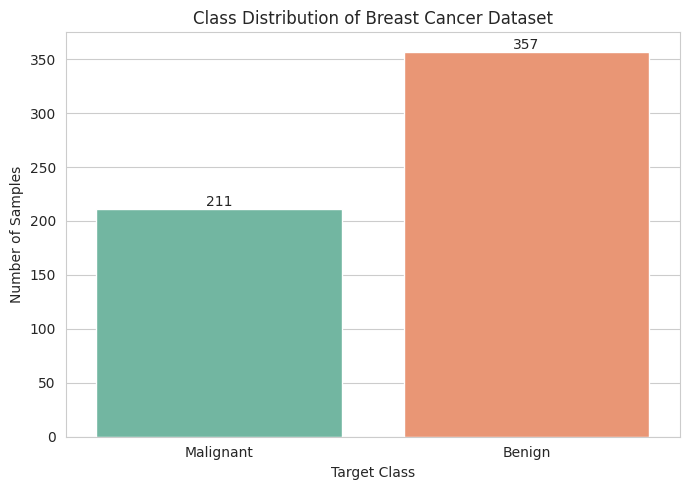

In [8]:
y = df.iloc[:, 1]
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x=y,
    hue=y,
    palette="Set2",
    legend=False
)

plt.title("Class Distribution of Breast Cancer Dataset")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Malignant", "Benign"])

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

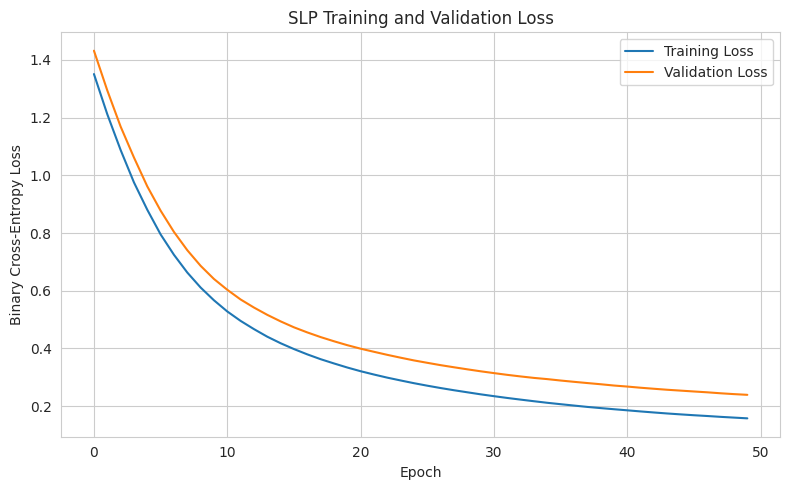

In [12]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode the target variable 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the SLP model
slp_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
slp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model and store history
slp_history = slp_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=0 # Suppress verbose output during training
)

plt.figure(figsize=(8, 5))

plt.plot(
    slp_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    slp_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("SLP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "slp_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

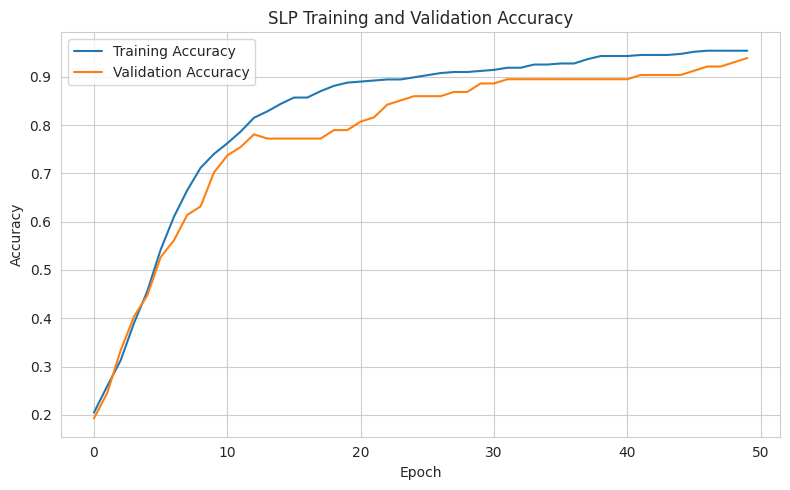

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    slp_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    slp_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("SLP Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "slp_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


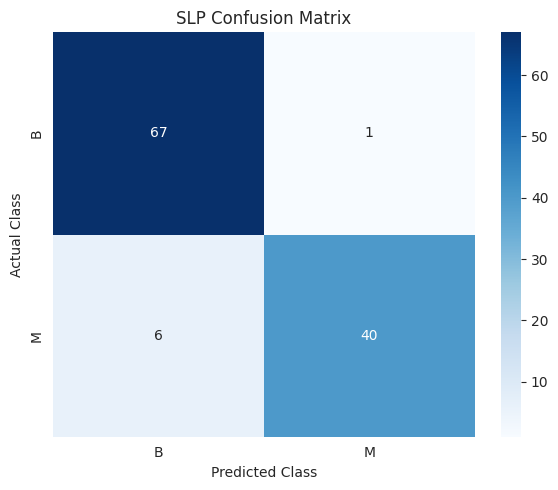

In [15]:
from sklearn.metrics import confusion_matrix

# Make predictions on the scaled test set
slp_predictions_proba = slp_model.predict(X_test_scaled)
slp_predictions = (slp_predictions_proba > 0.5).astype(int)

cm = confusion_matrix(y_test, slp_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("SLP Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "slp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

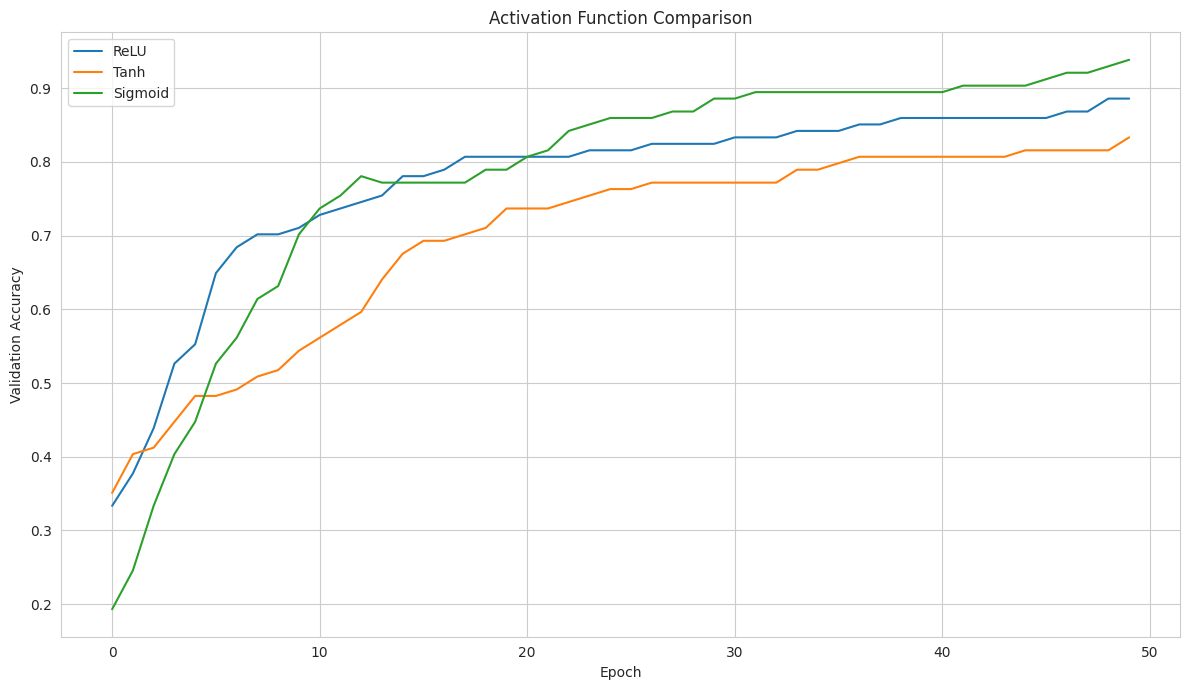

In [18]:
import tensorflow as tf

# Model definition, compilation, and training for ReLU activation
relu_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='relu') # ReLU activation
])
relu_model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Using binary_crossentropy as per the original problem setup
    metrics=['accuracy']
)
relu_history = relu_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=0
)

# Model definition, compilation, and training for Tanh activation
tanh_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='tanh') # Tanh activation
])
tanh_model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Using binary_crossentropy as per the original problem setup
    metrics=['accuracy']
)
tanh_history = tanh_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=0
)

# The slp_history from the previous cell corresponds to the Sigmoid activation model.
sigmoid_history = slp_history

plt.figure(figsize=(12, 7))

plt.plot(
    relu_history.history["val_accuracy"],
    label="ReLU"
)

plt.plot(
    tanh_history.history["val_accuracy"],
    label="Tanh"
)

plt.plot(
    sigmoid_history.history["val_accuracy"],
    label="Sigmoid"
)

plt.title("Activation Function Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "activation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

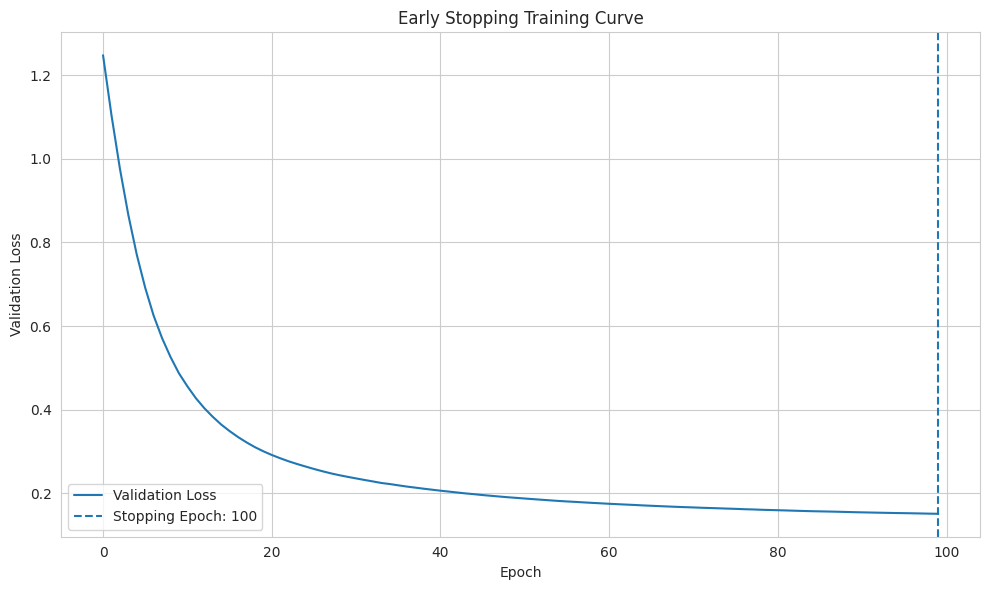

In [20]:
import tensorflow as tf

# Define EarlyStopping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Define a new SLP model for early stopping demonstration
early_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model (using the same settings as slp_model for consistency)
early_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model with early stopping and store history
early_history = early_model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a higher number of epochs, early stopping will stop it if needed
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping_callback],
    verbose=0 # Suppress verbose output during training
)

plt.figure(figsize=(10, 6))

plt.plot(
    early_history.history["val_loss"],
    label="Validation Loss"
)

# The actual stopping epoch is the length of the history, since restore_best_weights is True
# We subtract 1 because epochs are 0-indexed for plotting purposes (e.g., epoch 1 is index 0)
stopping_epoch = len(early_history.history["loss"])

plt.axvline(
    x=stopping_epoch - 1,
    linestyle="--",
    label=f"Stopping Epoch: {stopping_epoch}"
)

plt.title("Early Stopping Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "early_stopping.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

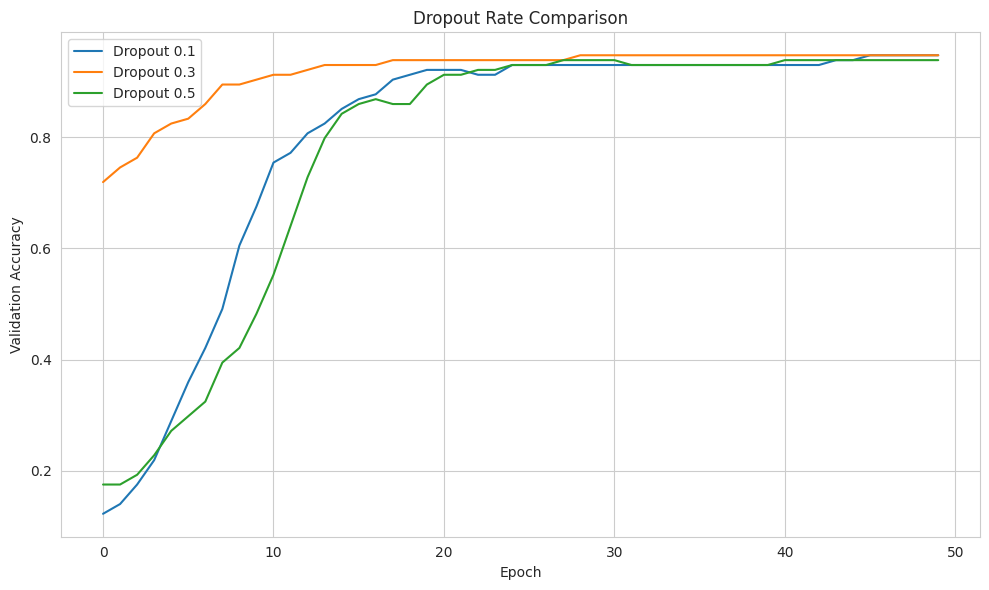

In [22]:
import tensorflow as tf

# Helper function to create and train a model with a given dropout rate
def create_and_train_dropout_model(dropout_rate):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dropout(dropout_rate), # Dropout layer
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_scaled, y_test),
        verbose=0
    )
    return history

# Train models with different dropout rates
dropout_01_history = create_and_train_dropout_model(0.1)
dropout_03_history = create_and_train_dropout_model(0.3)
dropout_05_history = create_and_train_dropout_model(0.5)


plt.figure(figsize=(10, 6))

plt.plot(
    dropout_01_history.history["val_accuracy"],
    label="Dropout 0.1"
)

plt.plot(
    dropout_03_history.history["val_accuracy"],
    label="Dropout 0.3"
)

plt.plot(
    dropout_05_history.history["val_accuracy"],
    label="Dropout 0.5"
)

plt.title("Dropout Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "dropout_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

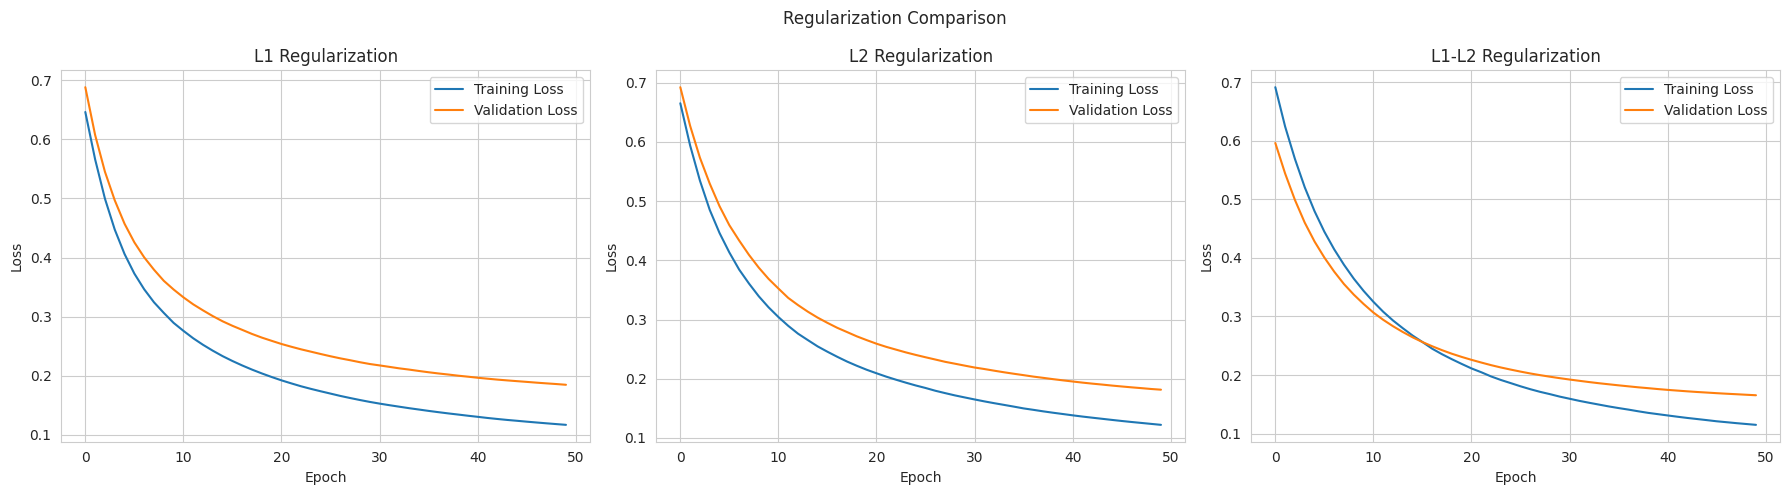

In [24]:
import tensorflow as tf
from tensorflow.keras import regularizers

# Helper function to create and train a model with a given kernel regularizer
def create_and_train_regularized_model(regularizer):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizer)
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_scaled, y_test),
        verbose=0
    )
    return history

# Train models with different regularization types
# L1 Regularization
l1_history = create_and_train_regularized_model(regularizers.L1(0.001))

# L2 Regularization
l2_history = create_and_train_regularized_model(regularizers.L2(0.001))

# L1 + L2 Regularization
l1_l2_history = create_and_train_regularized_model(regularizers.L1L2(l1=0.001, l2=0.001))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# L1
axes[0].plot(
    l1_history.history["loss"],
    label="Training Loss"
)
axes[0].plot(
    l1_history.history["val_loss"],
    label="Validation Loss"
)
axes[0].set_title("L1 Regularization")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# L2
axes[1].plot(
    l2_history.history["loss"],
    label="Training Loss"
)
axes[1].plot(
    l2_history.history["val_loss"],
    label="Validation Loss"
)
axes[1].set_title("L2 Regularization")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# L1 + L2
axes[2].plot(
    l1_l2_history.history["loss"],
    label="Training Loss"
)
axes[2].plot(
    l1_l2_history.history["val_loss"],
    label="Validation Loss"
)
axes[2].set_title("L1-L2 Regularization")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.suptitle("Regularization Comparison")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "regularization_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

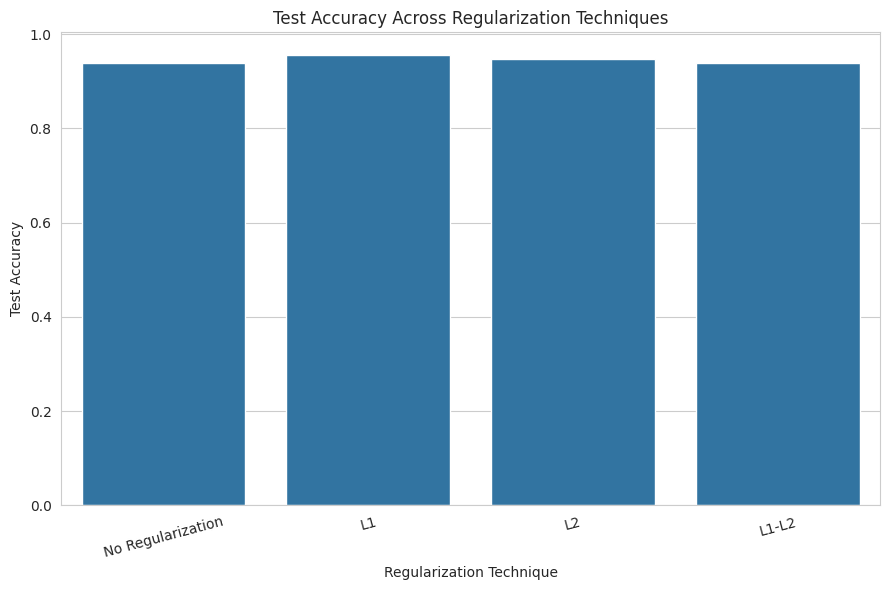

In [26]:
import tensorflow as tf
from tensorflow.keras import regularizers

# Helper function to create, train, and evaluate a model with a given kernel regularizer
def create_train_and_get_accuracy(regularizer=None):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizer)
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_scaled, y_test),
        verbose=0 # Suppress verbose output during training
    )
    _, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    return accuracy

# Calculate accuracies for different regularization techniques
no_reg_accuracy = create_train_and_get_accuracy(regularizer=None)
l1_accuracy = create_train_and_get_accuracy(regularizers.L1(0.001))
l2_accuracy = create_train_and_get_accuracy(regularizers.L2(0.001))
l1_l2_accuracy = create_train_and_get_accuracy(regularizers.L1L2(l1=0.001, l2=0.001))

regularization_names = [
    "No Regularization",
    "L1",
    "L2",
    "L1-L2"
]

regularization_accuracy = [
    no_reg_accuracy,
    l1_accuracy,
    l2_accuracy,
    l1_l2_accuracy
]

plt.figure(figsize=(9, 6))

sns.barplot(
    x=regularization_names,
    y=regularization_accuracy
)

plt.title("Test Accuracy Across Regularization Techniques")
plt.xlabel("Regularization Technique")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "regularization_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

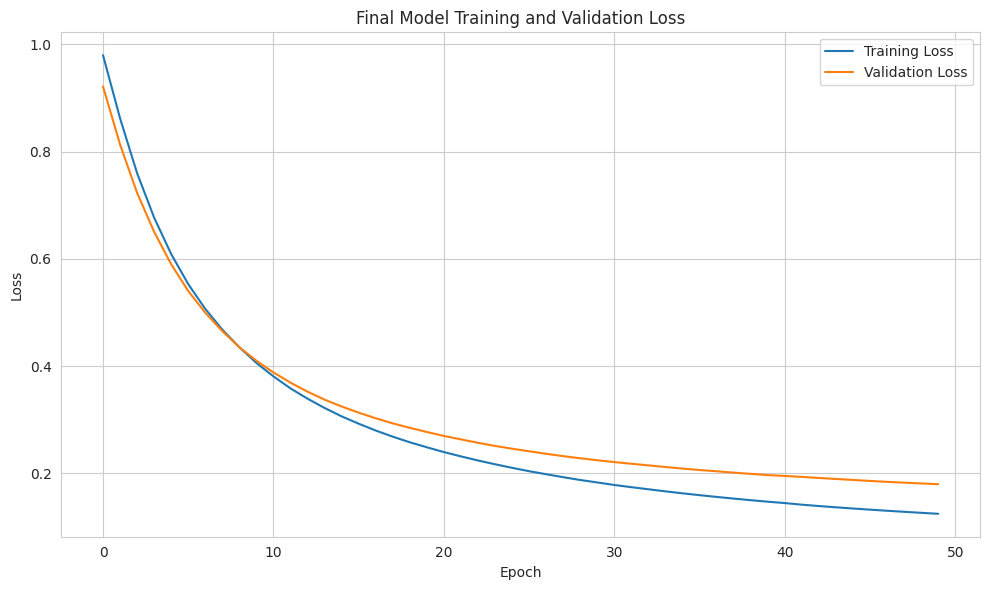

In [28]:
import tensorflow as tf

# Define the final model (e.g., a simple SLP as in previous steps)
final_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model and store history in final_history
final_history = final_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=0 # Suppress verbose output during training
)

plt.figure(figsize=(10, 6))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Final Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "final_model_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


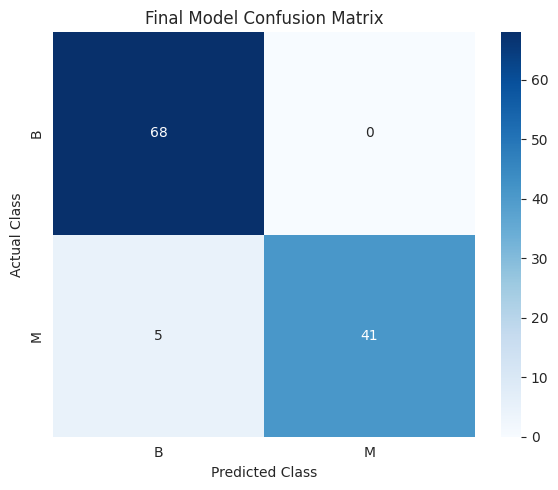

In [30]:
from sklearn.metrics import confusion_matrix

# Make predictions on the scaled test set using the final_model
final_predictions_proba = final_model.predict(X_test_scaled)
final_predictions = (final_predictions_proba > 0.5).astype(int)

cm_final = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_, # Use le.classes_ for proper labels if available
    yticklabels=le.classes_
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "final_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

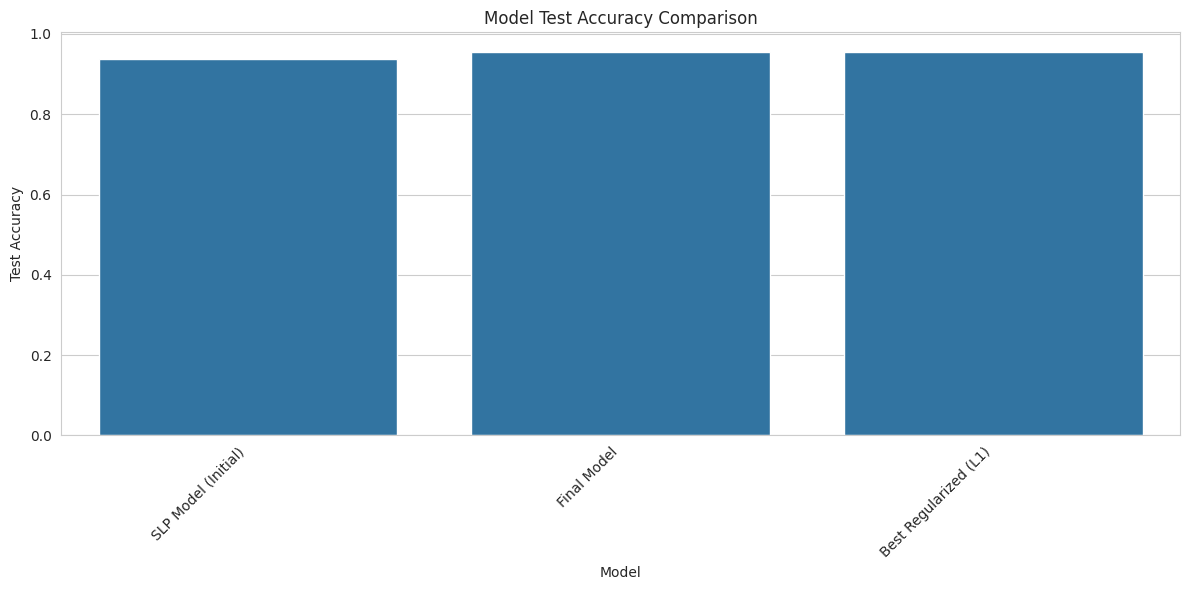

In [32]:
import pandas as pd

# Get the final validation accuracy for the SLP model
slp_final_accuracy = slp_history.history['val_accuracy'][-1]

# Get the final validation accuracy for the final model
final_model_accuracy = final_history.history['val_accuracy'][-1]

# Get the maximum accuracy from the regularization comparison
best_reg_accuracy = max(regularization_accuracy)
# Find the name of the best regularized model
best_reg_name_idx = regularization_accuracy.index(best_reg_accuracy)
best_reg_name = regularization_names[best_reg_name_idx]

# Create the DataFrame for model comparison
data = {
    "Model": ["SLP Model (Initial)", "Final Model", f"Best Regularized ({best_reg_name})"],
    "Test Accuracy": [slp_final_accuracy, final_model_accuracy, best_reg_accuracy]
}
results_df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test Accuracy"
)

plt.title("Model Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [36]:

plot_files = sorted(PLOTS_DIR.glob("*.png"))

print(f"Total plots generated: {len(plot_files)}")
print("\nGenerated files:")

for file in plot_files:
    print("✓", file)

Total plots generated: 13

Generated files:
✓ plots/activation_comparison.png
✓ plots/class_distribution.png
✓ plots/correlation_heatmap.png
✓ plots/dropout_comparison.png
✓ plots/early_stopping.png
✓ plots/final_model_confusion_matrix.png
✓ plots/final_model_training_curves.png
✓ plots/model_comparison.png
✓ plots/regularization_accuracy_comparison.png
✓ plots/regularization_comparison.png
✓ plots/slp_confusion_matrix.png
✓ plots/slp_training_accuracy.png
✓ plots/slp_training_loss.png
